Dataset link: https://www.kaggle.com/code/miadul/gaming-behavior-addiction-risk-prediction/input

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
import joblib
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Gaming and Mental Health.csv")
df.shape

(1000, 27)

In [3]:
df.isnull().sum()

record_id                             0
age                                   0
gender                                0
daily_gaming_hours                    0
game_genre                            0
primary_game                          0
gaming_platform                       0
sleep_hours                           0
sleep_quality                         0
sleep_disruption_frequency            0
academic_work_performance             0
grades_gpa                          246
work_productivity_score             326
mood_state                            0
mood_swing_frequency                  0
withdrawal_symptoms                   0
loss_of_other_interests               0
continued_despite_problems            0
eye_strain                            0
back_neck_pain                        0
weight_change_kg                      0
exercise_hours_weekly                 0
social_isolation_score                0
face_to_face_social_hours_weekly      0
monthly_game_spending_usd             0


In [4]:
# Drop record_id
df = df.drop(columns=["record_id"])

# Fill missing values
df["grades_gpa"] = df["grades_gpa"].fillna(df["grades_gpa"].median())
df["work_productivity_score"] = df["work_productivity_score"].fillna(df["work_productivity_score"].median())

In [5]:
df.isnull().sum()

age                                 0
gender                              0
daily_gaming_hours                  0
game_genre                          0
primary_game                        0
gaming_platform                     0
sleep_hours                         0
sleep_quality                       0
sleep_disruption_frequency          0
academic_work_performance           0
grades_gpa                          0
work_productivity_score             0
mood_state                          0
mood_swing_frequency                0
withdrawal_symptoms                 0
loss_of_other_interests             0
continued_despite_problems          0
eye_strain                          0
back_neck_pain                      0
weight_change_kg                    0
exercise_hours_weekly               0
social_isolation_score              0
face_to_face_social_hours_weekly    0
monthly_game_spending_usd           0
years_gaming                        0
gaming_addiction_risk_level         0
dtype: int64

In [6]:
X = df.drop(columns=["gaming_addiction_risk_level"])
y = df["gaming_addiction_risk_level"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nClass Distribution Before SMOTE:")
print(y.value_counts())

Feature Shape: (1000, 25)
Target Shape: (1000,)

Class Distribution Before SMOTE:
gaming_addiction_risk_level
Low         514
Moderate    190
High        154
Severe      142
Name: count, dtype: int64


In [8]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

# Apply OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_encoded = encoder.fit_transform(X[categorical_cols])

# Convert to dataframe
encoded_df = pd.DataFrame(
    X_encoded,
    columns=encoder.get_feature_names_out(categorical_cols)
)

# Drop original categorical columns
X_numeric = X.drop(columns=categorical_cols)

# Combine numeric + encoded
X_final = pd.concat([X_numeric.reset_index(drop=True),
                     encoded_df.reset_index(drop=True)], axis=1)

print("Shape After Encoding:", X_final.shape)


# Encode Target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded Classes:", label_encoder.classes_)


# Save encoders
joblib.dump(encoder, "onehot_encoder.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

Categorical Columns:
['gender', 'game_genre', 'primary_game', 'gaming_platform', 'sleep_quality', 'sleep_disruption_frequency', 'academic_work_performance', 'mood_state', 'mood_swing_frequency']
Shape After Encoding: (1000, 84)
Encoded Classes: ['High' 'Low' 'Moderate' 'Severe']


C:\Users\DELL\AppData\Local\Temp\ipykernel_7304\3556702338.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


['label_encoder.pkl']

In [9]:
# !pip install imbalanced-learn

In [11]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE
X_resampled, y_resampled = smote.fit_resample(X_final, y_encoded)

print("Shape After SMOTE:", X_resampled.shape)
print("\nClass Distribution After SMOTE:")
print(pd.Series(y_resampled).value_counts())

Shape After SMOTE: (2056, 84)

Class Distribution After SMOTE:
3    514
1    514
0    514
2    514
Name: count, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (1644, 84)
Test Shape: (412, 84)


In [14]:
test_df = pd.DataFrame(X_test)
test_df["target"] = y_test

test_df.to_csv("test.csv", index=False)

print("test.csv saved successfully")

test.csv saved successfully


In [16]:
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Scaled Train Shape:", X_train_scaled.shape)
print("Scaled Test Shape:", X_test_scaled.shape)

# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully")

Scaled Train Shape: (1644, 84)
Scaled Test Shape: (412, 84)
Scaler saved successfully


In [18]:
# Base models
base_models = [
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42)),
    ("gb", GradientBoostingClassifier()),
    ("svm", SVC(probability=True))
]

# Meta model
meta_model = LogisticRegression(max_iter=1000)

# Stacking model
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

# Train model
stacking_model.fit(X_train_scaled, y_train)

print("Model Training Completed")

# Save model
joblib.dump(stacking_model, "stacking_model.pkl")

print("Model saved as stacking_model.pkl")

Model Training Completed
Model saved as stacking_model.pkl


Model Accuracy: 0.9830097087378641

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       103
           1       1.00      0.99      1.00       103
           2       0.99      0.98      0.99       103
           3       0.98      0.98      0.98       103

    accuracy                           0.98       412
   macro avg       0.98      0.98      0.98       412
weighted avg       0.98      0.98      0.98       412


Confusion Matrix:
[[101   0   0   2]
 [  0 102   1   0]
 [  2   0 101   0]
 [  2   0   0 101]]


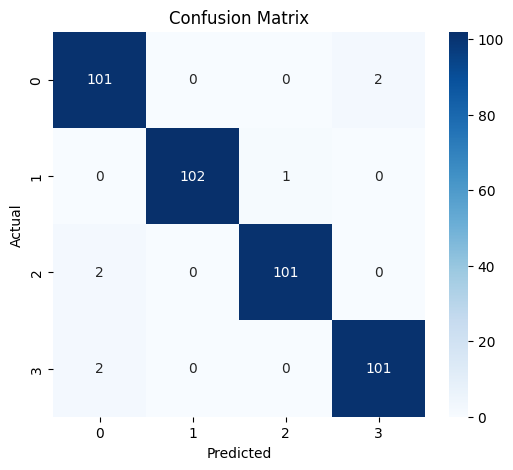

In [ ]:
# Predictions
y_pred = stacking_model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()